In [1]:
import os
import subprocess

data_dir = './lanl_data'
model_dir = './saved_models'
os.makedirs(data_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

print("Installing aria2 for multi-threaded downloading")
subprocess.run("sudo apt-get update > /dev/null 2>&1 && sudo apt-get install -y aria2 > /dev/null 2>&1", shell=True)

# Optimized to only download what this specific notebook needs
urls = {
    "redteam.txt.gz": "https://csr.lanl.gov/data-fence/1777876381/9usaCBU9obsPKD3bNQBQBzyXrI8=/cyber1/redteam.txt.gz",
    "flows.txt.gz": "https://csr.lanl.gov/data-fence/1777876381/9usaCBU9obsPKD3bNQBQBzyXrI8=/cyber1/flows.txt.gz"
}

Installing aria2 for multi-threaded downloading


In [2]:
for filename, url in urls.items():
    dest_path = os.path.join(data_dir, filename)
    if os.path.exists(dest_path) and os.path.getsize(dest_path) > 1024:
        print(f"{filename} already exists. Skipping.")
        continue
        
    print(f"\nDownloading {filename}...")
    cmd = ["aria2c", "-x", "16", "-s", "16", "-k", "1M", "--summary-interval=5", "--dir", data_dir, "--out", filename, url]
    subprocess.run(cmd)

print("\nDownloads completed successfully!")



05/04 10:18:36 [NOTICE] Downloading 1 item(s)

05/04 10:18:36 [NOTICE] Download complete: ./lanl_data/redteam.txt.gz

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
a99057|OK  |   676KiB/s|./lanl_data/redteam.txt.gz

Status Legend:
(OK):download completed.


05/04 10:18:36 [NOTICE] Downloading 1 item(s)
[#985041 9.7MiB/1.0GiB(0%) CN:16 DL:12MiB ETA:1m19s]
[#985041 32MiB/1.0GiB(3%) CN:16 DL:18MiB ETA:53s]
[#985041 61MiB/1.0GiB(5%) CN:16 DL:22MiB ETA:43s]
[#985041 97MiB/1.0GiB(9%) CN:16 DL:26MiB ETA:35s]
[#985041 131MiB/1.0GiB(12%) CN:16 DL:27MiB ETA:32s]
 *** Download Progress Summary as of Mon May  4 10:18:42 2026 *** 
[#985041 172MiB/1.0GiB(16%) CN:16 DL:30MiB ETA:28s]
FILE: ./lanl_data/flows.txt.gz
-------------------------------------------------------------------------------

[#985041 172MiB/1.0GiB(16%) CN:16 DL:30MiB ETA:28s]
[#985041 214MiB/1.0GiB(20%) CN:16 DL:32MiB ETA:25s]
[#985041 256MiB/1.0

In [3]:
import gc
import json
import pandas as pd
import numpy as np
import xgboost as xgb
import math
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score
import warnings
warnings.filterwarnings('ignore')

files = {
    "Flow": (os.path.join(data_dir, 'flows.txt.gz'), ['time', 'duration', 'src_comp', 'src_port', 'dest_comp', 'dest_port', 'protocol', 'pkt_cnt', 'byte_cnt']),
}
redteam_file = os.path.join(data_dir, 'redteam.txt.gz')

In [4]:
print("Loading Red Team ground truth data...")
red_cols = ['time', 'src_user', 'src_comp', 'dest_comp']
redteam_df = pd.read_csv(redteam_file, names=red_cols, na_values=['?'])

# Create a 1-hour bin for relaxed time matching
redteam_df['hour_bin'] = redteam_df['time'] // 3600
red_keys = set(zip(redteam_df['hour_bin'], redteam_df['src_comp']))

print(f"Loaded {len(redteam_df)} known malicious events.")

Loading Red Team ground truth data...
Loaded 749 known malicious events.


In [5]:
def scan_and_sample(filepath, columns, chunksize=15_000_000):
    print(f"\nScanning logs (~{os.path.getsize(filepath) / (1024**3):.1f} GB compressed)...")
    processed_chunks = []
    current_chunk = 0
    total_anomalies = 0
    
    for chunk in pd.read_csv(filepath, names=columns, chunksize=chunksize, dtype=str, na_values=['?']):
        current_chunk += 1
        chunk['time'] = pd.to_numeric(chunk['time'], errors='coerce').fillna(0).astype(np.int32)
        chunk['hour_bin'] = chunk['time'] // 3600
        
        # Apply the relaxed matching using the hour_bin and source computer
        chunk_keys = list(zip(chunk['hour_bin'], chunk['src_comp']))
        mask = pd.Series(chunk_keys).isin(red_keys).values
        
        anomalies = chunk[mask].copy()
        if not anomalies.empty:
            anomalies['is_anomaly'] = 1
            total_anomalies += len(anomalies)
        
        # Downsample benign traffic to 0.1% to manage memory and extreme imbalance
        benign = chunk[~mask].sample(frac=0.001, random_state=42).copy()
        benign['is_anomaly'] = 0
        
        processed_chunks.append(pd.concat([anomalies, benign]))
        if current_chunk % 5 == 0:
            print(f"  -> Scanned Chunk {current_chunk} | Anomalies Found: {total_anomalies}")

    print(f"Total Flow Anomalies Extracted: {total_anomalies}")
    return pd.concat(processed_chunks, ignore_index=True)

In [6]:
def engineer_flow(df):
    # Only duration and byte/packet counts are continuous numeric
    for col in ['duration', 'pkt_cnt', 'byte_cnt']:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype(np.float32)

    # Ports and Protocol are CATEGORICAL
    for col in ['src_port', 'dest_port', 'protocol']:
        df[col] = df[col].fillna("Missing").astype(str).astype('category')

    df['hour_of_day'] = (df['time'] % 86400) // 3600
    df['is_off_hours'] = df['hour_of_day'].apply(lambda x: 1 if x < 8 or x > 18 else 0).astype(np.int8)
    
    df['is_lateral_movement'] = np.where(df['dest_comp'].notna() & (df['dest_comp'] != "?"), 
                                         (df['src_comp'] != df['dest_comp']).astype(int), 0).astype(np.int8)
    
    # Payload intensity (Critical feature for C2 vs Exfiltration)
    df['bytes_per_packet'] = np.where(df['pkt_cnt'] > 0, df['byte_cnt'] / df['pkt_cnt'], 0).astype(np.float32)
    
    # Behavioral flags
    df['is_short_flow'] = np.where(df['duration'] < 2.0, 1, 0).astype(np.int8)
    df['is_long_flow'] = np.where(df['duration'] > 60.0, 1, 0).astype(np.int8)
        
    return df

In [7]:
def train_and_save_model(df, model_name, max_depth=8):
    print(f"\n{'='*40}")
    print(f" TRAINING MODEL: {model_name}")
    print(f"{'='*40}")
    
    # Sort chronologically to prevent Data Leakage!
    df = df.sort_values('time').reset_index(drop=True)
    
    # 80/20 Chronological Split
    split_idx = int(len(df) * 0.8)
    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]
    
    # Drop identifiers and timestamp so the model generalizes
    cols_to_drop = ['time', 'src_comp', 'dest_comp', 'hour_bin', 'is_anomaly']
    
    X_train = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns])
    y_train = train_df['is_anomaly'].astype(np.int8)
    
    X_test = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns])
    y_test = test_df['is_anomaly'].astype(np.int8)

    # Calculate the raw extreme imbalance
    raw_weight = len(y_train[y_train == 0]) / max(len(y_train[y_train == 1]), 1)
    scale_weight = math.sqrt(raw_weight) # Dampen to balance Precision and Recall
    
    # Enable categorical support natively in XGBoost
    import torch
    xgb_params = {
        'objective': 'binary:logistic',
        'tree_method': 'hist',
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'enable_categorical': True, 
        'n_estimators': 300,
        'learning_rate': 0.05,
        'max_depth': max_depth,
        'scale_pos_weight': scale_weight,
        'random_state': 42
    }
    
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n--- {model_name} Classification Report ---")
    print(classification_report(y_test, y_pred))
    
    auprc = average_precision_score(y_test, y_pred_proba)
    print(f"Area Under Precision-Recall Curve (AUPRC): {auprc:.4f}")
    
    # Save Model
    model_path = os.path.join(model_dir, f'lanl_{model_name.lower()}_xgb.json')
    model.save_model(model_path)
    
    # Save Metadata
    metadata = {
        "model_name": f"LANL_{model_name}_Anomaly_Detector",
        "algorithm": "XGBoost",
        "features": list(X_train.columns),
        "auprc_score": round(float(auprc), 4)
    }
    with open(os.path.join(model_dir, f'{model_name.lower()}_metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=4)
        
    print(f"-> Successfully saved {model_name} model & metadata.")
    
    # NEW: Return the test labels and probabilities so we can tune them outside the function
    return y_test, y_pred_proba

In [8]:
print("\n>>> Processing Network Flow Logs...")
df_flow = scan_and_sample(*files["Flow"])
df_flow = engineer_flow(df_flow)

# Capture the outputs!
y_test, y_pred_proba = train_and_save_model(df_flow, "Flow", max_depth=8) 

del df_flow
gc.collect()

print("\nPipeline execution completed successfully.")


>>> Processing Network Flow Logs...

Scanning logs (~1.0 GB compressed)...
  -> Scanned Chunk 5 | Anomalies Found: 23223
Total Flow Anomalies Extracted: 52447

 TRAINING MODEL: Flow

--- Flow Classification Report ---
              precision    recall  f1-score   support

           0       0.72      1.00      0.84     25606
           1       0.96      0.08      0.14     10869

    accuracy                           0.72     36475
   macro avg       0.84      0.54      0.49     36475
weighted avg       0.79      0.72      0.63     36475

Area Under Precision-Recall Curve (AUPRC): 0.8854
-> Successfully saved Flow model & metadata.

Pipeline execution completed successfully.


Default Threshold (0.500) F1-Score: 0.140
Optimal Threshold (0.005) F1-Score: 0.922

--- Classification Report (Optimal Threshold) ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.96     25606
           1       0.86      0.99      0.92     10869

    accuracy                           0.95     36475
   macro avg       0.93      0.96      0.94     36475
weighted avg       0.96      0.95      0.95     36475



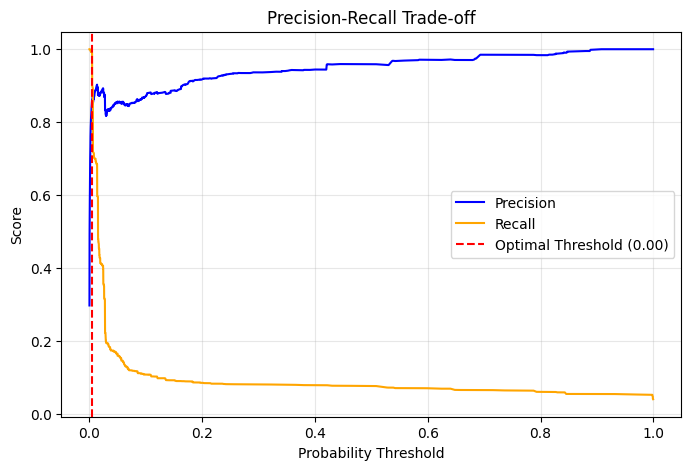

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
import numpy as np

# Calculate precision and recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate F1 score for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10) # 1e-10 avoids division by zero

# Find the threshold that gives the highest F1 Score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Default Threshold (0.500) F1-Score: 0.140")
print(f"Optimal Threshold ({best_threshold:.3f}) F1-Score: {best_f1:.3f}")

# Apply the new threshold
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)

print("\n--- Classification Report (Optimal Threshold) ---")
print(classification_report(y_test, y_pred_optimal))

# Plot the Trade-off
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color='blue')
plt.plot(thresholds, recalls[:-1], label="Recall", color='orange')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({best_threshold:.2f})')
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.grid(alpha=0.3)
plt.show()